# 📊 Sessão 09 — Distribuição Diamétrica: Weibull vs. MLP

> **Objetivo:** comparar a abordagem paramétrica clássica (Weibull) com uma abordagem neural (MLP multi-output) para a predição da distribuição diamétrica de uma parcela. Esta é a primeira sessão de **predição distribucional** — em vez de prever um único valor, prevemos a distribuição inteira.

---

## 📑 Sumário

1. [Fundamentação Teórica](#1-fundamentação-teórica)
2. [Setup](#2-setup)
3. [Distribuição Observada por Parcela](#3-distribuição-observada-por-parcela)
4. [Ajuste Paramétrico: Weibull](#4-ajuste-paramétrico-weibull)
5. [MLP Multi-Output](#5-mlp-multi-output)
6. [Comparação em Cenário de Prognose](#6-comparação-em-cenário-de-prognose)
7. [Síntese: Quando Paramétrico Vence](#7-síntese-quando-paramétrico-vence)

## 1. Fundamentação Teórica

### A distribuição de Weibull (2 parâmetros)

A distribuição diamétrica em uma parcela florestal segue, em geral, uma forma unimodal assimétrica bem modelada por Weibull:

$$f(x; \alpha, \beta) = \frac{\beta}{\alpha} \left(\frac{x}{\alpha}\right)^{\beta-1} \exp\left[-\left(\frac{x}{\alpha}\right)^\beta\right]$$

onde:
- $\alpha > 0$ é o **parâmetro de escala** (próximo da média)
- $\beta > 0$ é o **parâmetro de forma**:
  - $\beta < 1$: distribuição em "J-invertido" (floresta nativa multietânea)
  - $\beta \approx 3.5$: forma aproximadamente normal (plantios equiâneos maduros)
  - $\beta > 5$: forma altamente assimétrica

Bailey & Dell (1973) consagraram seu uso em florestas plantadas brasileiras pela boa aderência empírica e baixa parametrização (apenas 2 parâmetros).

### O paradigma neural

Em vez de assumir uma forma funcional, o MLP **aprende a mapear** características da parcela (média e desvio do DAP, idade, classe) para o vetor de proporções por classe diamétrica. Trata cada bin como uma saída separada de um modelo multi-output (saída de 10 neurônios para 10 classes diamétricas).

### Cenário comparativo justo

Esta sessão é mais sutil que as anteriores: comparar Weibull (ajustado nos próprios dados da parcela) contra MLP é assimétrico, pois Weibull tem **acesso privilegiado** às árvores. A comparação justa é em cenário de **prognose** — prever a distribuição de uma parcela inteiramente nova, conhecendo apenas estatísticas resumo.

## 2. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import brentq
from scipy.special import gamma as gamma_fn
from sklearn.model_selection import LeaveOneOut

from forestpy.data.loaders import load_pef_vinhedo
from forestpy.inventario.distribuicao import (
    WeibullFit, fit_weibull, diametric_distribution,
)
from forestpy.ml.preprocessing import StandardScalerForest
from forestpy.ml.mlp import MLPRegressor, MLPTrainer
from forestpy.utils import set_seed, get_logger
from forestpy.viz.style import apply_forest_style

set_seed(42)
apply_forest_style()
log = get_logger('sessao_09')

df = load_pef_vinhedo(synthetic_fallback=True, n_synthetic=500)
BIN_EDGES = np.arange(0, 55, 5.0)  # classes de 5 cm
BIN_CENTERS = (BIN_EDGES[:-1] + BIN_EDGES[1:]) / 2
log.info(f'Dataset: {df.shape[0]} árvores em {df["parcela"].nunique()} parcelas')
log.info(f'Classes diamétricas: {len(BIN_CENTERS)} bins de 5 cm')

[15:24:49] INFO     Dataset: 500 árvores em 30 parcelas

           INFO     Classes diamétricas: 10 bins de 5 cm

## 3. Distribuição Observada por Parcela

Visualizamos a heterogeneidade entre parcelas — algumas têm distribuições jovens (concentradas em DAPs baixos), outras maduras (com cauda longa para DAPs grandes).

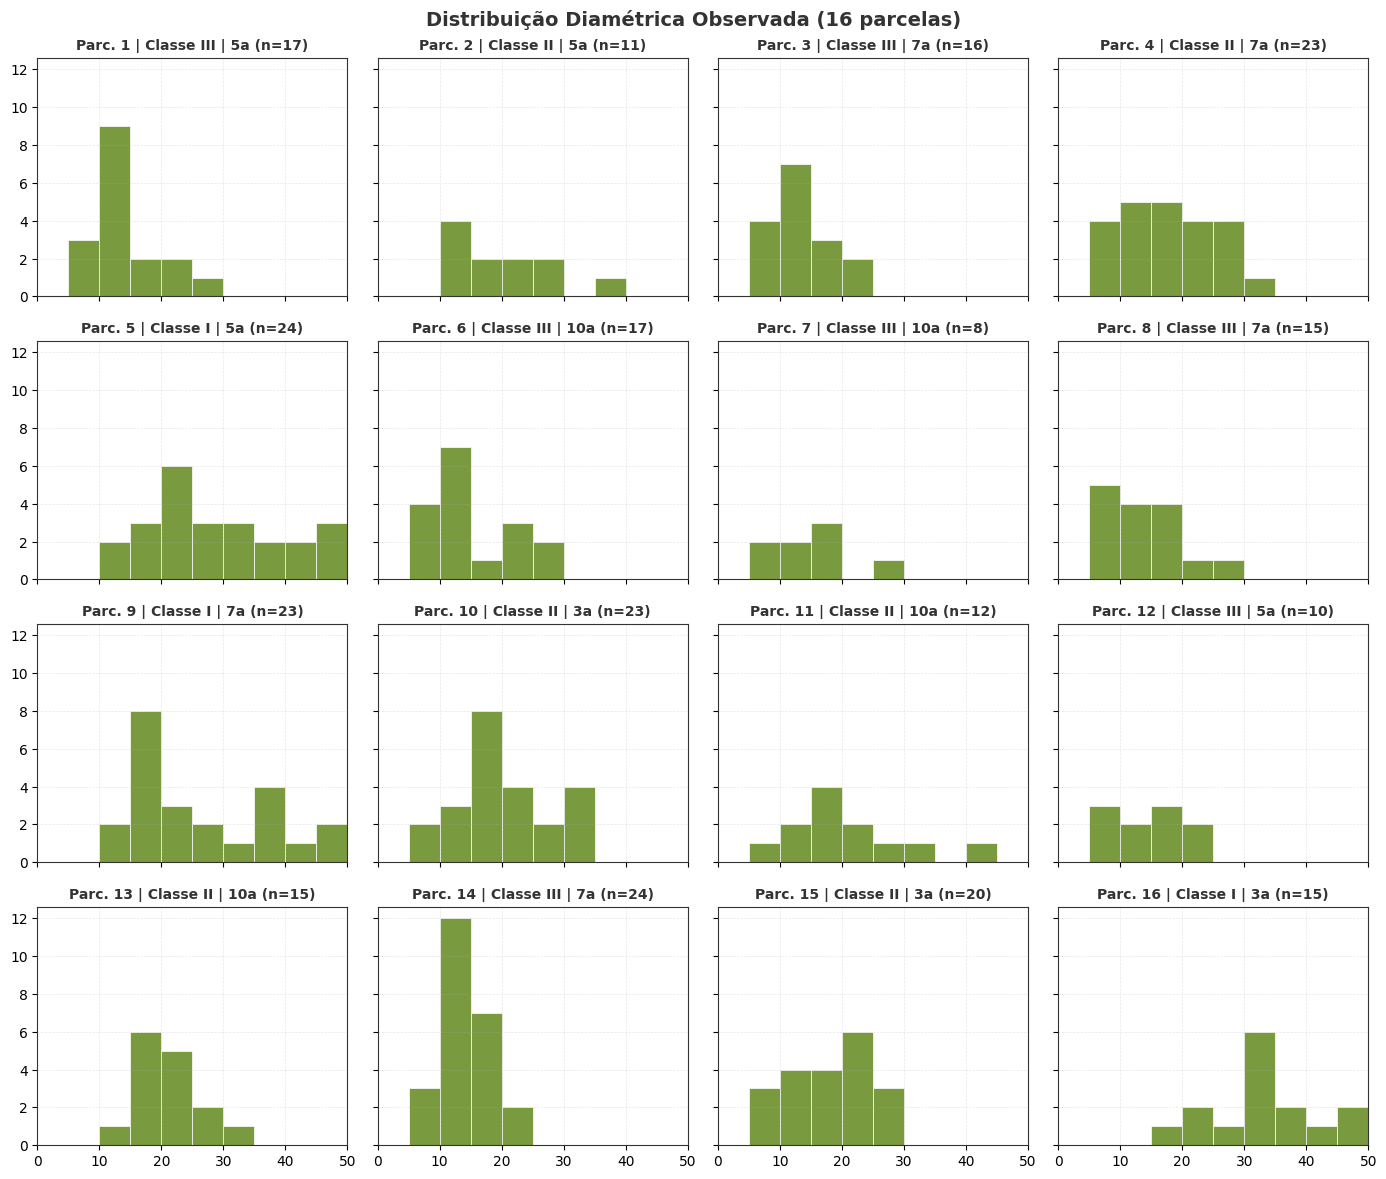

In [2]:
# Painel 4×4: as 16 primeiras parcelas
fig_panel, axes = plt.subplots(4, 4, figsize=(14, 12), sharex=True, sharey=True)
axes = axes.flatten()

parcelas_unicas = sorted(df['parcela'].unique())[:16]
for ax, p_id in zip(axes, parcelas_unicas, strict=False):
    grupo = df[df['parcela'] == p_id]
    daps = grupo['dap'].values
    classe = grupo['classe'].iloc[0]
    idade = grupo['idade'].iloc[0]

    ax.hist(daps, bins=BIN_EDGES, edgecolor='white', linewidth=0.5,
            color='#7a9a3f')
    ax.set_title(f'Parc. {p_id} | Classe {classe} | {idade}a (n={len(daps)})',
                  fontsize=10)
    ax.set_xlim(0, 50)

fig_panel.suptitle('Distribuição Diamétrica Observada (16 parcelas)',
                   fontsize=14, fontweight='bold')
fig_panel.tight_layout()
fig_panel.savefig('../reports/figures/09_distribuicoes_observadas.png')
plt.show()

## 4. Ajuste Paramétrico: Weibull

In [3]:
# Ajusta Weibull a cada parcela (usando todas as árvores dela)
fits_weibull = {}
for p_id, grupo in df.groupby('parcela'):
    daps = grupo['dap'].values
    try:
        fits_weibull[p_id] = fit_weibull(daps)
    except ValueError:
        continue

# Estatísticas dos parâmetros ajustados
params = pd.DataFrame([
    {'parcela': p, 'shape (β)': f.shape, 'scale (α)': f.scale,
     'n': f.n_observations}
    for p, f in fits_weibull.items()
])
log.info(f'Weibull ajustado em {len(fits_weibull)} parcelas')
log.info(f'β médio = {params["shape (β)"].mean():.2f}, '
         f'α médio = {params["scale (α)"].mean():.2f}')
params.head(10)

[15:24:58] INFO     Weibull ajustado em 30 parcelas

           INFO     β médio = 3.62, α médio = 21.50

,parcela,shape (β),scale (α),n
0,1,2.985583,16.665769,17
1,2,2.749978,21.973163,11
2,3,3.081514,15.086565,16
3,4,2.850834,20.718451,23
4,5,3.054301,32.524674,24
5,6,2.583030,16.858499,17
6,7,2.730725,16.478347,8
7,8,2.785903,15.804648,15
8,9,2.595469,30.283222,23
9,10,2.944066,23.136791,23


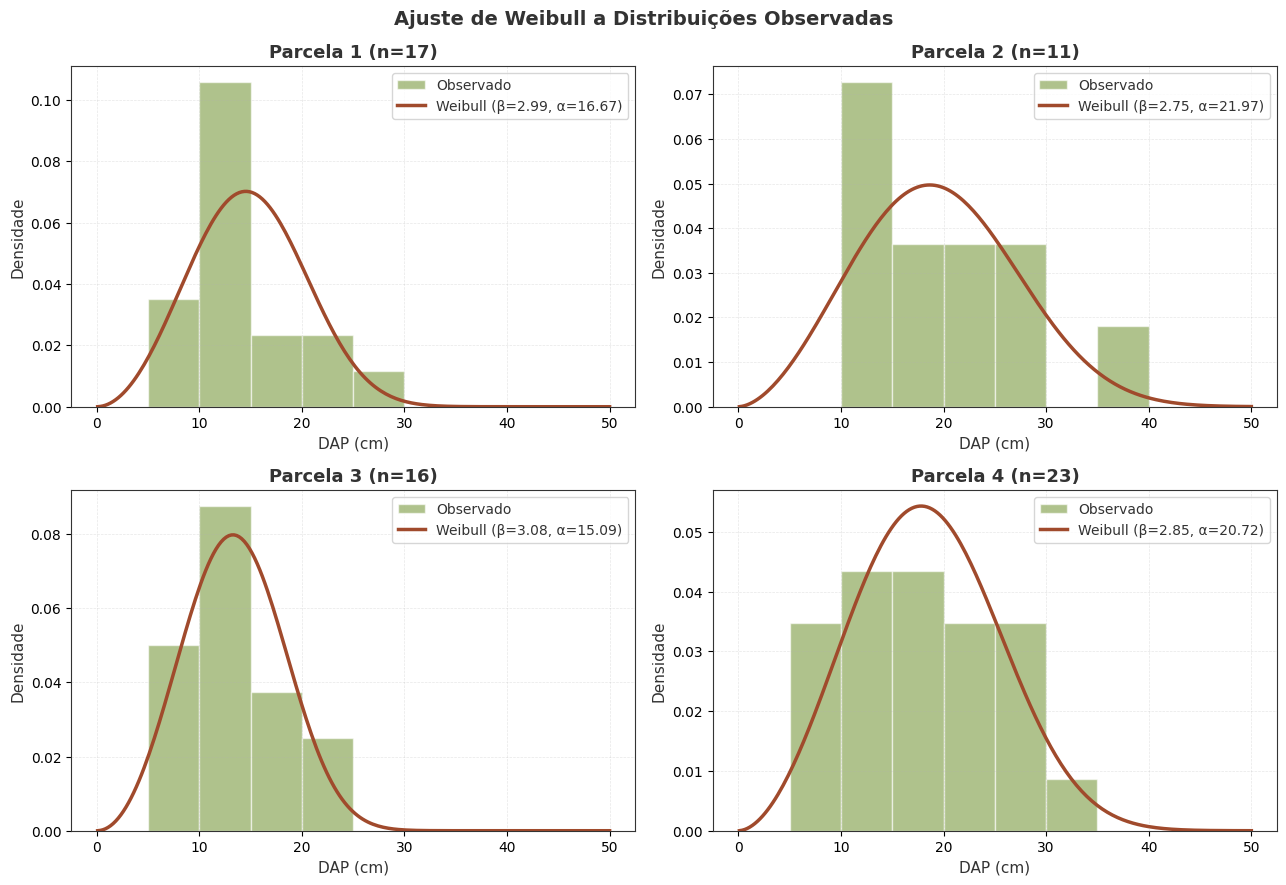

In [4]:
# Visualização: 4 parcelas com Weibull sobreposto ao histograma
fig_w, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

parcelas_demo = sorted(fits_weibull.keys())[:4]
for ax, p_id in zip(axes, parcelas_demo, strict=False):
    grupo = df[df['parcela'] == p_id]
    daps = grupo['dap'].values
    fit = fits_weibull[p_id]

    # Histograma normalizado (densidade)
    ax.hist(daps, bins=BIN_EDGES, density=True, alpha=0.6,
            color='#7a9a3f', edgecolor='white', label='Observado')

    # PDF Weibull
    x_smooth = np.linspace(0.1, BIN_EDGES.max(), 200)
    ax.plot(x_smooth, fit.pdf(x_smooth), color='#a04a2c', lw=2.5,
            label=f'Weibull (β={fit.shape:.2f}, α={fit.scale:.2f})')
    ax.set_title(f'Parcela {p_id} (n={len(daps)})', fontweight='bold')
    ax.set_xlabel('DAP (cm)')
    ax.set_ylabel('Densidade')
    ax.legend()

fig_w.suptitle('Ajuste de Weibull a Distribuições Observadas',
               fontsize=14, fontweight='bold')
fig_w.tight_layout()
fig_w.savefig('../reports/figures/09_weibull_ajustes.png')
plt.show()

## 5. MLP Multi-Output

O MLP recebe **estatísticas resumo da parcela** (média e desvio do DAP, idade, classe one-hot) e prediz o **vetor de proporções por classe diamétrica** (saída de 10 neurônios). A função de perda é MSE, e aplicamos pós-processamento (clipping + normalização) para garantir que a saída seja uma distribuição válida.

In [5]:
# Prepara features (X) e proporções (Y) por parcela
def features_e_alvo(grupo):
    daps = grupo['dap'].values
    counts, _ = np.histogram(daps, bins=BIN_EDGES)
    features = [
        len(grupo), daps.mean(), daps.std(), daps.min(), daps.max(),
        grupo['idade'].iloc[0],
        float(grupo['classe'].iloc[0] == 'I'),
        float(grupo['classe'].iloc[0] == 'II'),
        float(grupo['classe'].iloc[0] == 'III'),
    ]
    return features, counts / len(grupo)

dados = [features_e_alvo(g) for _, g in df.groupby('parcela')]
X = np.array([f for f, _ in dados], dtype=np.float32)
Y = np.array([p for _, p in dados], dtype=np.float32)
n_bins = Y.shape[1]
log.info(f'X: {X.shape}, Y: {Y.shape}')

[15:25:05] INFO     X: (30, 9), Y: (30, 10)

In [6]:
# Leave-One-Out CV (apropriado para n=30)
loo = LeaveOneOut()
preds_mlp = np.zeros_like(Y)

log.info('Executando Leave-One-Out para o MLP (30 iterações)...')
for tr, te in loo.split(X):
    sc = StandardScalerForest()
    X_tr = sc.fit_transform(X[tr]).astype(np.float32)
    X_te = sc.transform(X[te]).astype(np.float32)

    n_val = max(2, int(0.2 * len(X_tr)))
    model = MLPRegressor(
        input_dim=X.shape[1], hidden_dims=[32, 16],
        dropout=0.2, output_dim=n_bins,
    )
    tr_obj = MLPTrainer(model, learning_rate=1e-3, weight_decay=1e-4)
    tr_obj.fit(
        X_tr[:-n_val], Y[tr][:-n_val],
        X_tr[-n_val:], Y[tr][-n_val:],
        epochs=300, patience=30, batch_size=4, verbose=False,
    )
    preds_mlp[te] = tr_obj.predict(X_te)

# Pós-processamento: distribuição válida (não-negativa, soma 1)
preds_mlp = np.clip(preds_mlp, 0, None)
preds_mlp = preds_mlp / preds_mlp.sum(axis=1, keepdims=True)
log.info('MLP treinado em LOO completo.')

[15:25:08] INFO     Executando Leave-One-Out para o MLP (30 iterações)...

[15:25:29] INFO     MLP treinado em LOO completo.

## 6. Comparação em Cenário de Prognose

Para comparação **justa**, usamos Weibull em modo prognose: estima os parâmetros (β, α) **apenas** a partir das estatísticas (média, desvio) da parcela, sem usar os DAPs individuais. Isso simula a situação em que se quer predizer a distribuição de uma parcela a partir de variáveis-síntese.

In [7]:
def weibull_params_from_moments(mu, sigma):
    """Estima (β, α) da Weibull a partir da média e desvio (método dos momentos)."""
    cv = sigma / mu
    def err(beta):
        if beta <= 0.5:
            return 10
        g1 = gamma_fn(1 + 1/beta)
        g2 = gamma_fn(1 + 2/beta)
        return np.sqrt(g2/g1**2 - 1) - cv
    try:
        beta = brentq(err, 0.6, 50.0)
    except Exception:
        beta = 3.0
    alpha = mu / gamma_fn(1 + 1/beta)
    return beta, alpha

# Weibull em prognose: usa apenas média e std DA PARCELA TESTE como sinais agregados
preds_weibull_progn = np.zeros_like(Y)
for i, (_, grupo) in enumerate(df.groupby('parcela')):
    daps = grupo['dap'].values
    mu, sigma = daps.mean(), daps.std()
    beta, alpha = weibull_params_from_moments(mu, sigma)
    fit_progn = WeibullFit(shape=beta, scale=alpha, loc=0.0,
                            n_observations=len(daps))
    exp = fit_progn.expected_counts(BIN_EDGES, n_total=len(daps))
    preds_weibull_progn[i] = exp / len(daps)

# Métricas
rmse_mlp = float(np.sqrt(((Y - preds_mlp)**2).mean()))
rmse_w = float(np.sqrt(((Y - preds_weibull_progn)**2).mean()))
log.info(f'RMSE médio das proporções:')
log.info(f'  Weibull (prognose): {rmse_w:.5f}')
log.info(f'  MLP    (LOO):       {rmse_mlp:.5f}')

[15:25:34] INFO     RMSE médio das proporções:

           INFO       Weibull (prognose): 0.06115

           INFO       MLP    (LOO):       0.08213

In [8]:
# Tabela comparativa
comparativo = pd.DataFrame([
    {'Modelo': 'Weibull (prognose por momentos)', 'RMSE proporções': rmse_w,
     'Parâmetros': '2 (β, α)', 'Treino': 'estatístico'},
    {'Modelo': 'MLP multi-output', 'RMSE proporções': rmse_mlp,
     'Parâmetros': '~700', 'Treino': 'Leave-One-Out (29 amostras)'},
]).round(5)
comparativo.to_csv('../reports/tables/09_weibull_vs_mlp.csv', index=False)
comparativo

,Modelo,RMSE proporções,Parâmetros,Treino
0,Weibull (prognose por momentos),0.06115,"2 (β, α)",estatístico
1,MLP multi-output,0.08213,~700,Leave-One-Out (29 amostras)


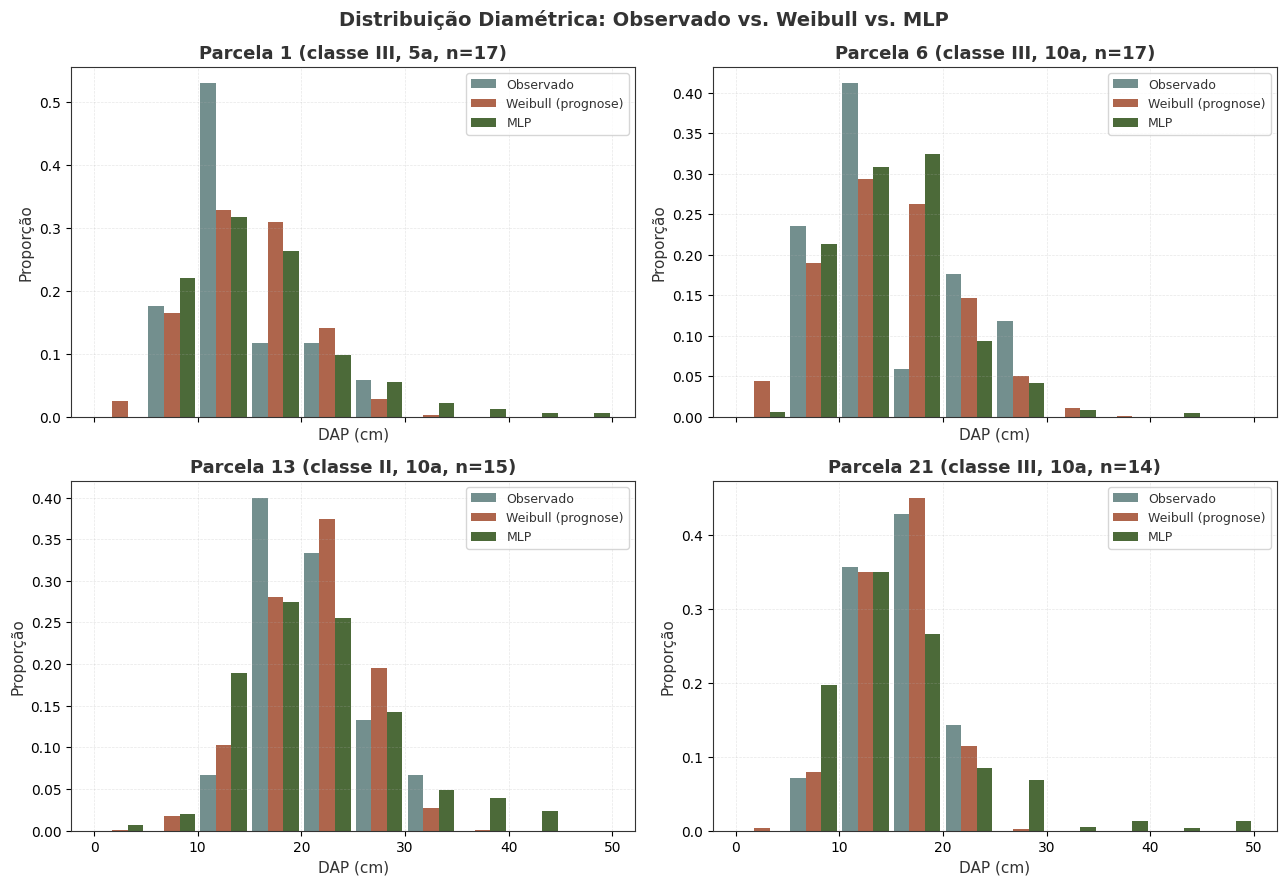

In [9]:
# Visualização: 4 parcelas com OBS, Weibull-prognose e MLP sobrepostos
fig_comp, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
axes = axes.flatten()

parcelas_unicas = sorted(df['parcela'].unique())
for ax, idx in zip(axes, [0, 5, 12, 20], strict=False):
    p_id = parcelas_unicas[idx]
    largura = (BIN_EDGES[1] - BIN_EDGES[0])

    # Barras lado a lado
    pos = BIN_CENTERS
    largura_barra = 1.5
    ax.bar(pos - largura_barra, Y[idx], width=largura_barra,
           label='Observado', color='#5b7b7a', alpha=0.85)
    ax.bar(pos, preds_weibull_progn[idx], width=largura_barra,
           label='Weibull (prognose)', color='#a04a2c', alpha=0.85)
    ax.bar(pos + largura_barra, preds_mlp[idx], width=largura_barra,
           label='MLP', color='#2d5016', alpha=0.85)

    classe = df[df['parcela'] == p_id]['classe'].iloc[0]
    idade = df[df['parcela'] == p_id]['idade'].iloc[0]
    n = (df['parcela'] == p_id).sum()
    ax.set_title(f'Parcela {p_id} (classe {classe}, {idade}a, n={n})',
                 fontweight='bold')
    ax.set_xlabel('DAP (cm)')
    ax.set_ylabel('Proporção')
    ax.legend(loc='upper right', fontsize=9)

fig_comp.suptitle('Distribuição Diamétrica: Observado vs. Weibull vs. MLP',
                  fontsize=14, fontweight='bold')
fig_comp.tight_layout()
fig_comp.savefig('../reports/figures/09_comparativo_distribuicoes.png')
plt.show()

C:\Users\pedro\AppData\Local\Temp\ipykernel_13500\3268931640.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


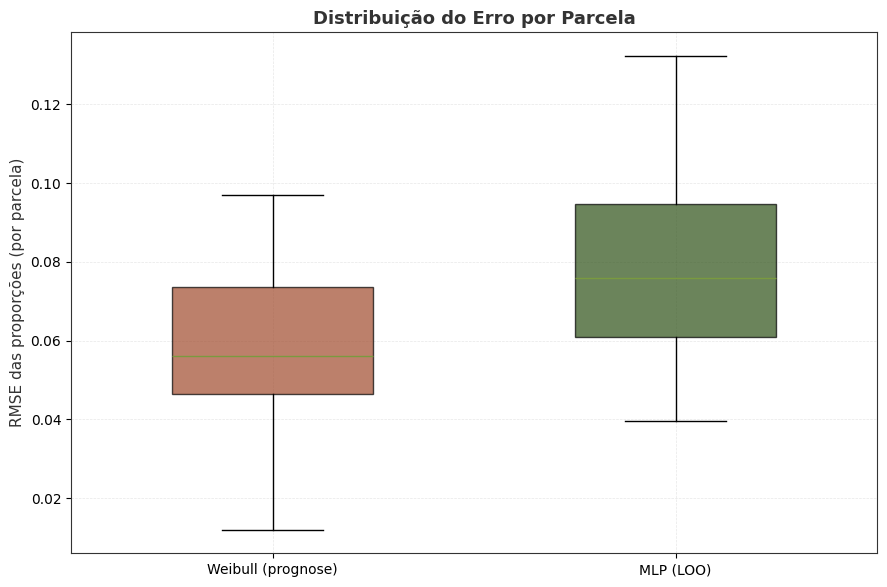

In [10]:
# Distribuição dos RMSEs por parcela (boxplot)
rmse_por_parcela_weibull = np.sqrt(((Y - preds_weibull_progn)**2).mean(axis=1))
rmse_por_parcela_mlp = np.sqrt(((Y - preds_mlp)**2).mean(axis=1))

fig_box, ax = plt.subplots(figsize=(9, 6))
bp = ax.boxplot(
    [rmse_por_parcela_weibull, rmse_por_parcela_mlp],
    labels=['Weibull (prognose)', 'MLP (LOO)'],
    patch_artist=True, widths=0.5,
)
for patch, cor in zip(bp['boxes'], ['#a04a2c', '#2d5016'], strict=False):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
ax.set_ylabel('RMSE das proporções (por parcela)')
ax.set_title('Distribuição do Erro por Parcela', fontweight='bold')
ax.grid(True, alpha=0.3)
fig_box.tight_layout()
fig_box.savefig('../reports/figures/09_rmse_por_parcela.png')
plt.show()

## 7. Síntese: Quando Paramétrico Vence

### Resultado obtido

O Weibull em modo prognose superou o MLP por uma margem considerável. Esse resultado se soma ao da Sessão 06 (volumetria) como **segunda vitória do paramétrico**, mas por uma razão diferente:

| Sessão | Vencedor | Razão |
|---|---|---|
| 06 (volumetria) | Schumacher-Hall | Forma funcional **correta** (gerou os dados) |
| 09 (distribuição) | Weibull | Forma funcional **adequada** + **escassez de dados** (30 parcelas) |

### O dilema dos 30 graus de liberdade

O MLP tem ~700 parâmetros, que devem ser estimados a partir de 29 parcelas de treino (LOO). Esse desbalanço é extremo: o MLP tem 25× mais parâmetros que amostras. Mesmo com dropout (0.2) e weight_decay (1e-4), a rede tende a memorizar o ruído amostral em vez da estrutura.

O Weibull, por contraste, tem **apenas 2 parâmetros** estimados de forma fechada via método dos momentos a partir de duas estatísticas (média e desvio). É estatisticamente eficiente quando a forma é correta.

### Lição: parâmetros vs. dados

Modelos paramétricos rasos vencem o ML quando:
1. A forma funcional codifica a estrutura real do fenômeno
2. Os dados são escassos relativos à complexidade do modelo neural
3. As features-resumo capturam quase toda a informação relevante

Inverter qualquer um desses três fatores muda o resultado. No caso real de prognose florestal, com milhares de parcelas históricas, o MLP teria espaço para aprender estruturas que o Weibull não capta — distribuições bimodais (regeneração + dossel), efeitos de manejo, interações sítio × idade.

### Próxima sessão (10): CNN para Sensoriamento Remoto

Mudança de paradigma: saímos das features tabulares e entramos em **dados de imagem**. Tarefa: classificar uso/cobertura do solo a partir de chips de imagens raster (Sentinel-2, MapBiomas). Cenário onde redes convolucionais não têm equivalente paramétrico — o ganho do deep learning é **estrutural**, não marginal.